In [13]:
import pandas as pd

df = pd.read_excel("/content/customer_reatil.csv.xlsx")

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [14]:
df["PurchaseType"] = (df["Quantity"] > 10).astype(int)

print(df[["Quantity", "PurchaseType"]].head(10))

   Quantity  PurchaseType
0         6             0
1         6             0
2         8             0
3         6             0
4         6             0
5         2             0
6         6             0
7         6             0
8         6             0
9        32             1


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Country"] = le.fit_transform(df["Country"])

print(df[["Country"]].head(10))

   Country
0       36
1       36
2       36
3       36
4       36
5       36
6       36
7       36
8       36
9       36


In [16]:
X = df[["Quantity", "UnitPrice", "Country"]]

y = df["PurchaseType"]

print(X.head())
print(y.head())

   Quantity  UnitPrice  Country
0         6       2.55       36
1         6       3.39       36
2         8       2.75       36
3         6       3.39       36
4         6       3.39       36
0    0
1    0
2    0
3    0
4    0
Name: PurchaseType, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 433527
Testing rows: 108382


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 1.0


In [19]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

from sklearn.metrics import accuracy_score

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 1.0


In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.9999907733756528


In [21]:
from sklearn.metrics import confusion_matrix

print("Logistic Regression")
print(confusion_matrix(y_test, lr_pred))

print("\nDecision Tree")
print(confusion_matrix(y_test, dt_pred))

print("\nKNN")
print(confusion_matrix(y_test, knn_pred))

Logistic Regression
[[82035     0]
 [    0 26347]]

Decision Tree
[[82035     0]
 [    0 26347]]

KNN
[[82035     0]
 [    1 26346]]


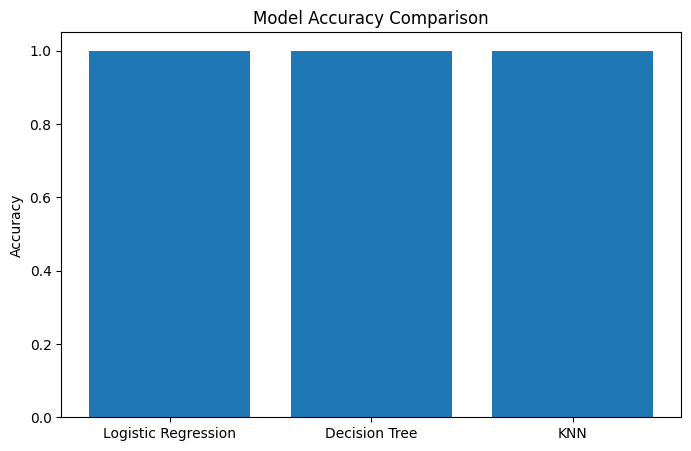

In [22]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "KNN"]
accuracies = [lr_acc, dt_acc, knn_acc]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()